# Data Mining – Preprocessing

Cleaning, resampling, feature engineering, weather enrichment and scaling of the UCI *Individual Household Electric Power Consumption* dataset.

**Setup**
1. Run the first code cell: it clones the repository (weather data and output folder) into the Colab session.
2. Download and unzip the raw dataset from the [UCI repository](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption). It is not included in this repository (it is too large for GitHub).
3. In the Colab file browser (left), open the folder `smart-home-energy-data-mining/Notebooks` (click ⟳ if it does not show up) and upload `household_power_consumption.txt` there.
4. Run the rest of the notebook.


In [ ]:
# Setup: clone the repository (weather data + output folder) and define the paths
import os, subprocess

REPO_URL = "https://github.com/PetrosV00/smart-home-energy-data-mining.git"
REPO_DIR = "smart-home-energy-data-mining"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

# Raw UCI dataset: upload it to <repo>/Notebooks/ (see the note above)
DATA_PATH = os.path.join(REPO_DIR, "Notebooks", "household_power_consumption.txt")
WEATHER_PATH = os.path.join(REPO_DIR, "CSV-pickles", "weather_conditions.csv")
OUTPUT_DIR = os.path.join(REPO_DIR, "CSV-pickles")

if not os.path.exists(DATA_PATH):
    print(f"Next step: upload household_power_consumption.txt to the folder '{os.path.dirname(DATA_PATH)}' (Colab file browser, left), then continue.")


In [ ]:
# Read dataset.txt to csv format
import pandas as pd

df = pd.read_csv(
  DATA_PATH,
    sep = ";",
    na_values = "?"
)
df.info()
# How many NaN i have in the whole dataset (each column)
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [ ]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [ ]:
df[df.isnull().any(axis=1)]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,21/12/2006,11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,30/12/2006,10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,30/12/2006,10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,14/1/2007,18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1990185,28/9/2010,19:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990186,28/9/2010,19:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990187,28/9/2010,19:11:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990188,28/9/2010,19:12:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [ ]:
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})

In [ ]:
missing_value_df

,column_name,percent_missing
Date,Date,0.000000
Time,Time,0.000000
Global_active_power,Global_active_power,1.251844
Global_reactive_power,Global_reactive_power,1.251844
Voltage,Voltage,1.251844
Global_intensity,Global_intensity,1.251844
Sub_metering_1,Sub_metering_1,1.251844
Sub_metering_2,Sub_metering_2,1.251844
Sub_metering_3,Sub_metering_3,1.251844


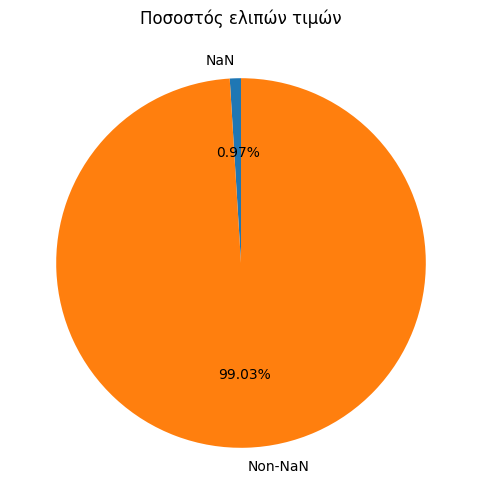

In [ ]:
import matplotlib.pyplot as plt

total_cells = df.shape[0] * df.shape[1]
total_nans = df.isna().sum().sum()
total_non_nans = total_cells - total_nans

plt.figure(figsize=(6,6))
plt.pie(
    [total_nans, total_non_nans],
    labels=["NaN", "Non-NaN"],
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Ποσοστός ελιπών τιμών")
plt.show()

# Θελω ποσοστό ανα στήλη

In [ ]:
# New Feature
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.drop(columns=['Date', 'Time'], inplace=True)
df.set_index('Datetime', inplace=True)



df.info()
df.index


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00', '2006-12-16 17:29:00',
               '2006-12-16 17:30:00', '2006-12-16 17:31:00',
               '2006-12-16 17:32:00', '2006-12-16 17:33:00',
               ...
               '2010-11-26 20:53:00', '2010-11-26 20:54:00',
               '2010-11-26 20:55:00', '2010-11-26 20:56:00',
               '2010-11-26 20:57:00', '2010-11-26 20:58:00',
               '2010-11-26 20:59:00', '2010-11-26 21:00:00',
               '2010-11-26 21:01:00', '2010-11-26 21:02:00'],
              dtype='datetime64[ns]', name='Datetime', length=2075259, freq=None)

In [ ]:
# Handle negative regord
# Show negative regord
(df < 0).sum()

# Any regord that is not a number will be NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Evry negative regord is NaN for All columns
df = df.mask(df < 0)

df.isna().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


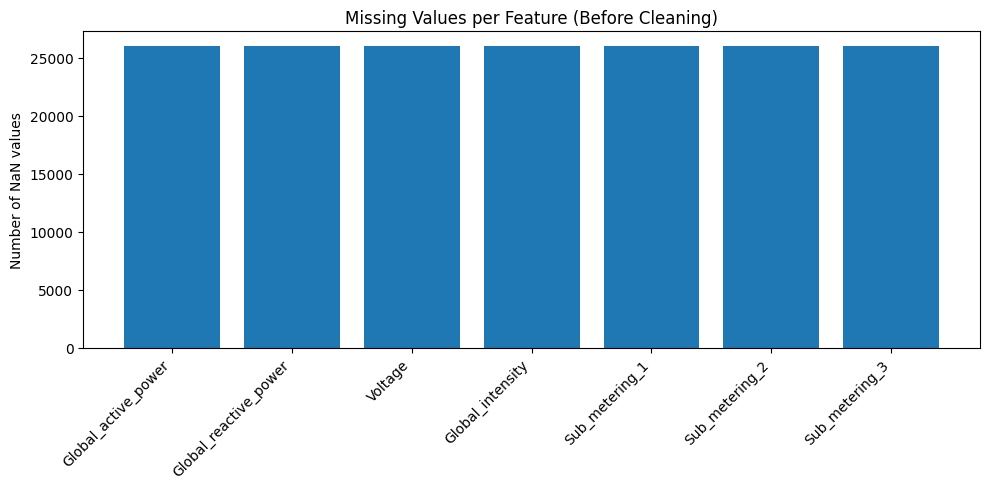

In [ ]:
import matplotlib.pyplot as plt

nan_counts = df.isna().sum()

plt.figure(figsize=(10,5))
plt.bar(nan_counts.index, nan_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of NaN values")
plt.title("Missing Values per Feature (Before Cleaning)")
plt.tight_layout()
plt.show()


In [ ]:
# Με βάση τον χρονκό άξονα κοιτάει την προηγούμενη και την επόμενη
# και βγάζει την μέση τιμή
df = df.interpolate(method='time', limit = 30 )
df.isna().sum()

df.dropna(inplace=True)
df.isna().sum()



,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


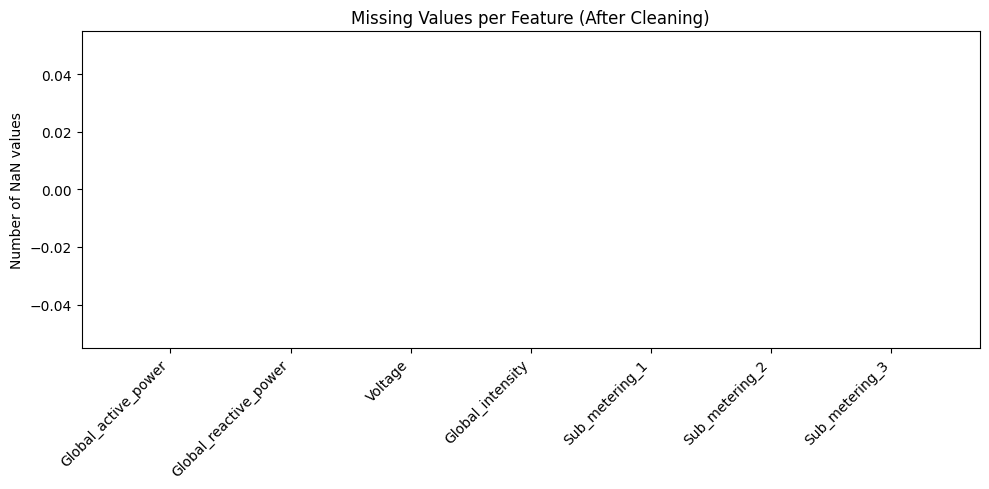

In [ ]:
# Δεν έχει τοσο νόημα

import matplotlib.pyplot as plt

nan_counts = df.isna().sum()

plt.figure(figsize=(10,5))
plt.bar(nan_counts.index, nan_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of NaN values")
plt.title("Missing Values per Feature (After Cleaning)")
plt.tight_layout()
plt.show()


In [ ]:
df['Global_active_power_kWh'] = df['Global_active_power'] / 60
df['Sub_metering_1_kWh'] = df['Sub_metering_1'] / 1000
df['Sub_metering_2_kWh'] = df['Sub_metering_2'] / 1000
df['Sub_metering_3_kWh'] = df['Sub_metering_3'] / 1000

In [ ]:
df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power_kWh,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh
Datetime,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,0.070267,0.0,0.001,0.017
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,0.089333,0.0,0.001,0.016
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,0.089567,0.0,0.002,0.017
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,0.089800,0.0,0.001,0.017
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,0.061100,0.0,0.001,0.017
...,...,...,...,...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0,0.015767,0.0,0.000,0.000
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0,0.015733,0.0,0.000,0.000
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0,0.015633,0.0,0.000,0.000


In [ ]:
# Resampling
daily_df = df.resample('D').sum()
daily_df.head()
daily_df.shape
daily_df.isna().sum()

daily_df['Daily_total_power'] = daily_df['Global_active_power_kWh']

daily_df.drop(columns=[
              'Global_active_power',
              'Global_reactive_power',
              'Voltage',
              'Global_intensity',
              'Sub_metering_1',
              'Sub_metering_2',
              'Sub_metering_3',
              'Global_active_power_kWh'],
              inplace=True)
#  if a day missing the consamption is 0
#daily_df = daily_df.fillna(0)

In [ ]:
daily_df

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power
Datetime,,,,
2006-12-16,0.000,0.546,4.926,20.152933
2006-12-17,2.033,4.187,13.341,56.507667
2006-12-18,1.063,2.621,14.018,36.730433
2006-12-19,0.839,7.602,6.197,27.769900
2006-12-20,0.000,2.648,14.063,37.095800
...,...,...,...,...
2010-11-22,4.855,2.110,10.136,34.025600
2010-11-23,1.871,0.458,7.611,26.292267
2010-11-24,1.096,2.848,12.224,29.937467


In [ ]:
peak = df.between_time('18:00', '22:00').resample('D').sum()
daily_df['Peak_hour_power'] = peak['Global_active_power_kWh']

night = df.between_time('00:00', '06:00').resample('D').sum()
daily_df['Nighttime_usage'] = night['Global_active_power_kWh']

#weekend = daily_df[daily_df.index.weekday >= 5]
#daily_df['Weekend_usage'] = weekend['Global_active_power_kWh']

daily_df['Day_of_week'] = daily_df.index.day_of_week  # 0=Δευτέρα
daily_df['Month'] = daily_df.index.month

def season(month):
    if month in [12, 1, 2]: return 0
    if month in [3, 4, 5]: return 1
    if month in [6, 7, 8]: return 2
    return 3

daily_df['Season'] = daily_df['Month'].apply(season)

def is_workDay(day):
    if day >= 5: return float(1)
    return float(0)

daily_df['is_workDay'] = daily_df['Day_of_week'].apply(is_workDay)

daily_df.dropna(inplace=True)



In [ ]:
daily_df

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power,Peak_hour_power,Nighttime_usage,Day_of_week,Month,Season,is_workDay
Datetime,,,,,,,,,,
2006-12-17,2.033,4.187,13.341,56.507667,13.052600,12.728433,6,12,0,1.0
2006-12-18,1.063,2.621,14.018,36.730433,10.263267,2.507467,0,12,0,0.0
2006-12-19,0.839,7.602,6.197,27.769900,8.452633,2.464267,1,12,0,0.0
2006-12-20,0.000,2.648,14.063,37.095800,13.368667,2.370300,2,12,0,0.0
2006-12-21,1.765,2.623,10.421,28.618567,8.064967,5.053533,3,12,0,0.0
...,...,...,...,...,...,...,...,...,...,...
2010-11-22,4.855,2.110,10.136,34.025600,9.764367,1.864167,0,11,3,0.0
2010-11-23,1.871,0.458,7.611,26.292267,8.145067,1.858633,1,11,3,0.0
2010-11-24,1.096,2.848,12.224,29.937467,7.452467,2.485533,2,11,3,0.0


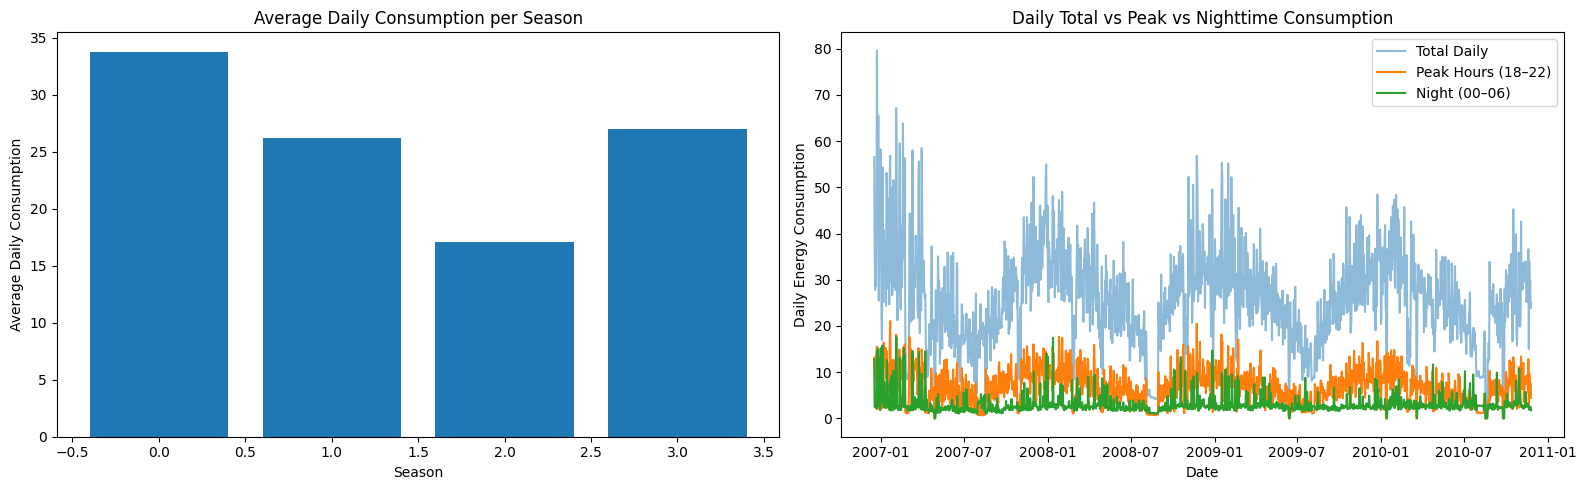

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# ─────────────────────────────
# 1️⃣ Bar chart: Season average
# ─────────────────────────────
season_avg = daily_df.groupby('Season')['Daily_total_power'].mean()

axes[0].bar(season_avg.index, season_avg.values)
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average Daily Consumption")
axes[0].set_title("Average Daily Consumption per Season")

# ─────────────────────────────
# 2️⃣ Line plot: Daily vs Peak vs Night
# ─────────────────────────────
axes[1].plot(
    daily_df.index,
    daily_df['Daily_total_power'],
    label='Total Daily',
    alpha=0.5
)
axes[1].plot(
    daily_df.index,
    daily_df['Peak_hour_power'],
    label='Peak Hours (18–22)'
)
axes[1].plot(
    daily_df.index,
    daily_df['Nighttime_usage'],
    label='Night (00–06)'
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily Energy Consumption")
axes[1].set_title("Daily Total vs Peak vs Nighttime Consumption")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
daily_df['Consumption'] = float(0)

daily_df.loc[daily_df['Daily_total_power'] > daily_df['Daily_total_power'].median() , 'Consumption'] = float(1)


In [ ]:
daily_df

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power,Peak_hour_power,Nighttime_usage,Day_of_week,Month,Season,is_workDay,Consumption
Datetime,,,,,,,,,,,
2006-12-17,2.033,4.187,13.341,56.507667,13.052600,12.728433,6,12,0,1.0,1.0
2006-12-18,1.063,2.621,14.018,36.730433,10.263267,2.507467,0,12,0,0.0,1.0
2006-12-19,0.839,7.602,6.197,27.769900,8.452633,2.464267,1,12,0,0.0,1.0
2006-12-20,0.000,2.648,14.063,37.095800,13.368667,2.370300,2,12,0,0.0,1.0
2006-12-21,1.765,2.623,10.421,28.618567,8.064967,5.053533,3,12,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2010-11-22,4.855,2.110,10.136,34.025600,9.764367,1.864167,0,11,3,0.0,1.0
2010-11-23,1.871,0.458,7.611,26.292267,8.145067,1.858633,1,11,3,0.0,1.0
2010-11-24,1.096,2.848,12.224,29.937467,7.452467,2.485533,2,11,3,0.0,1.0


In [ ]:
daily_df[['Daily_total_power']].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1441 entries, 2006-12-17 to 2010-11-26
Freq: D
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Daily_total_power  1441 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB


Εμπλουτισμός του Dataset με δεδομένα καιρού

In [ ]:
weather_df = pd.read_csv(WEATHER_PATH)

In [ ]:
weather_df.drop([0,1], axis=0, inplace=True)
weather_df.drop(columns=['timezone_abbreviation'], inplace=True)

weather_df.rename(columns={
    'latitude': 'Datetime',
    'longitude': 'Min_Temp',
    'elevation': 'Max_Temp',
    'utc_offset_seconds': 'Mean_Humidity_Percentage',
    'timezone': 'Cloud_cover_Mean_Percentage'}, inplace=True)

weather_df['Datetime'] = pd.to_datetime(weather_df['Datetime'])

weather_df.set_index('Datetime', inplace=True)
weather_df

,Min_Temp,Max_Temp,Mean_Humidity_Percentage,Cloud_cover_Mean_Percentage
Datetime,,,,
2006-12-16,3.3,8.4,93,84
2006-12-17,-0.2,7.0,95,73
2006-12-18,1.1,5.2,96,88
2006-12-19,0.6,4.2,89,32
2006-12-20,-0.9,4.7,86,8
...,...,...,...,...
2010-11-22,3.6,5.4,88,99
2010-11-23,1.1,6.9,89,72
2010-11-24,0.8,6.4,90,50


In [ ]:
df_updated = pd.concat([daily_df, weather_df], axis=1)
df_updated.dropna(inplace=True)
df_updated

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power,Peak_hour_power,Nighttime_usage,Day_of_week,Month,Season,is_workDay,Consumption,Min_Temp,Max_Temp,Mean_Humidity_Percentage,Cloud_cover_Mean_Percentage
Datetime,,,,,,,,,,,,,,,
2006-12-17,2.033,4.187,13.341,56.507667,13.052600,12.728433,6.0,12.0,0.0,1.0,1.0,-0.2,7.0,95,73
2006-12-18,1.063,2.621,14.018,36.730433,10.263267,2.507467,0.0,12.0,0.0,0.0,1.0,1.1,5.2,96,88
2006-12-19,0.839,7.602,6.197,27.769900,8.452633,2.464267,1.0,12.0,0.0,0.0,1.0,0.6,4.2,89,32
2006-12-20,0.000,2.648,14.063,37.095800,13.368667,2.370300,2.0,12.0,0.0,0.0,1.0,-0.9,4.7,86,8
2006-12-21,1.765,2.623,10.421,28.618567,8.064967,5.053533,3.0,12.0,0.0,0.0,1.0,0.0,6.7,92,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-11-22,4.855,2.110,10.136,34.025600,9.764367,1.864167,0.0,11.0,3.0,0.0,1.0,3.6,5.4,88,99
2010-11-23,1.871,0.458,7.611,26.292267,8.145067,1.858633,1.0,11.0,3.0,0.0,1.0,1.1,6.9,89,72
2010-11-24,1.096,2.848,12.224,29.937467,7.452467,2.485533,2.0,11.0,3.0,0.0,1.0,0.8,6.4,90,50


In [ ]:
df_updated.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1441 entries, 2006-12-17 to 2010-11-26
Freq: D
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sub_metering_1_kWh           1441 non-null   float64
 1   Sub_metering_2_kWh           1441 non-null   float64
 2   Sub_metering_3_kWh           1441 non-null   float64
 3   Daily_total_power            1441 non-null   float64
 4   Peak_hour_power              1441 non-null   float64
 5   Nighttime_usage              1441 non-null   float64
 6   Day_of_week                  1441 non-null   float64
 7   Month                        1441 non-null   float64
 8   Season                       1441 non-null   float64
 9   is_workDay                   1441 non-null   float64
 10  Consumption                  1441 non-null   float64
 11  Min_Temp                     1441 non-null   object 
 12  Max_Temp                     1441 non-null   objec

In [ ]:
import numpy as np

df_updated['Min_Temp_forecast'] = df_updated['Min_Temp'].shift(-1)
df_updated['Max_Temp_forecast'] = df_updated['Max_Temp'].shift(-1)
df_updated['Mean_Humidity_Percentage_forecast'] = df_updated['Mean_Humidity_Percentage'].shift(-1)
df_updated['Cloud_cover_Mean_Percentage_forecast'] = df_updated['Cloud_cover_Mean_Percentage'].shift(-1)

df_updated['Next_Days_Consumption'] = df_updated['Daily_total_power'].shift(-1)
df_updated['Prev_Days_Consumption'] = df_updated['Daily_total_power'].shift(1)

df_updated['WeekAgo_Consumption'] = df_updated['Daily_total_power'].shift(7)

#df_updated['Daily_sin'] = np.sin(2 * np.pi * df_updated['Day_of_week'] / 7)
#df_updated['Daily_cos'] = np.cos(2 * np.pi * df_updated['Day_of_week'] / 7)

#df_updated['Month_sin'] = np.sin(2 * np.pi * df_updated['Month'] / 12)
#df_updated['Month_cos'] = np.cos(2 * np.pi * df_updated['Month'] / 12)

#df_updated.drop(columns=['Min_Temp', 'Max_Temp', 'Mean_Humidity_Percentage','Cloud_cover_Mean_Percentage'], inplace=True)

In [ ]:
df_updated.dropna(inplace=True)
df_updated

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power,Peak_hour_power,Nighttime_usage,Day_of_week,Month,Season,is_workDay,...,Max_Temp,Mean_Humidity_Percentage,Cloud_cover_Mean_Percentage,Min_Temp_forecast,Max_Temp_forecast,Mean_Humidity_Percentage_forecast,Cloud_cover_Mean_Percentage_forecast,Next_Days_Consumption,Prev_Days_Consumption,WeekAgo_Consumption
Datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-24,1.703,5.082,6.891,42.500200,1.927300,14.463500,6.0,12.0,0.0,1.0,...,2.5,92,96,-0.2,2.6,96,100,45.718667,79.556433,56.507667
2006-12-25,6.620,1.962,5.795,45.718667,9.926567,4.436667,0.0,12.0,0.0,0.0,...,2.6,96,100,-0.3,1.2,93,100,65.568500,42.500200,36.730433
2006-12-26,1.086,2.533,14.979,65.568500,12.430567,15.108267,1.0,12.0,0.0,0.0,...,1.2,93,100,-0.5,1.1,83,99,25.479333,45.718667,27.769900
2006-12-27,0.000,0.314,6.976,25.479333,7.265533,3.417267,2.0,12.0,0.0,0.0,...,1.1,83,99,-1.6,2.6,89,96,34.543967,65.568500,37.095800
2006-12-28,2.207,4.419,9.176,34.543967,12.610633,2.517700,3.0,12.0,0.0,0.0,...,2.6,89,96,-2.4,5.6,82,86,52.906533,25.479333,28.618567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-11-21,0.000,0.506,4.778,15.015167,2.597367,2.679067,6.0,11.0,3.0,1.0,...,7.2,93,100,3.6,5.4,88,99,34.025600,36.616767,33.973200
2010-11-22,4.855,2.110,10.136,34.025600,9.764367,1.864167,0.0,11.0,3.0,0.0,...,5.4,88,99,1.1,6.9,89,72,26.292267,15.015167,29.123033
2010-11-23,1.871,0.458,7.611,26.292267,8.145067,1.858633,1.0,11.0,3.0,0.0,...,6.9,89,72,0.8,6.4,90,50,29.937467,34.025600,25.162467


In [ ]:
df_updated.to_pickle(os.path.join(OUTPUT_DIR, 'df_denormanized.pkl'))

Κανονικοποίηση Δεδομένων

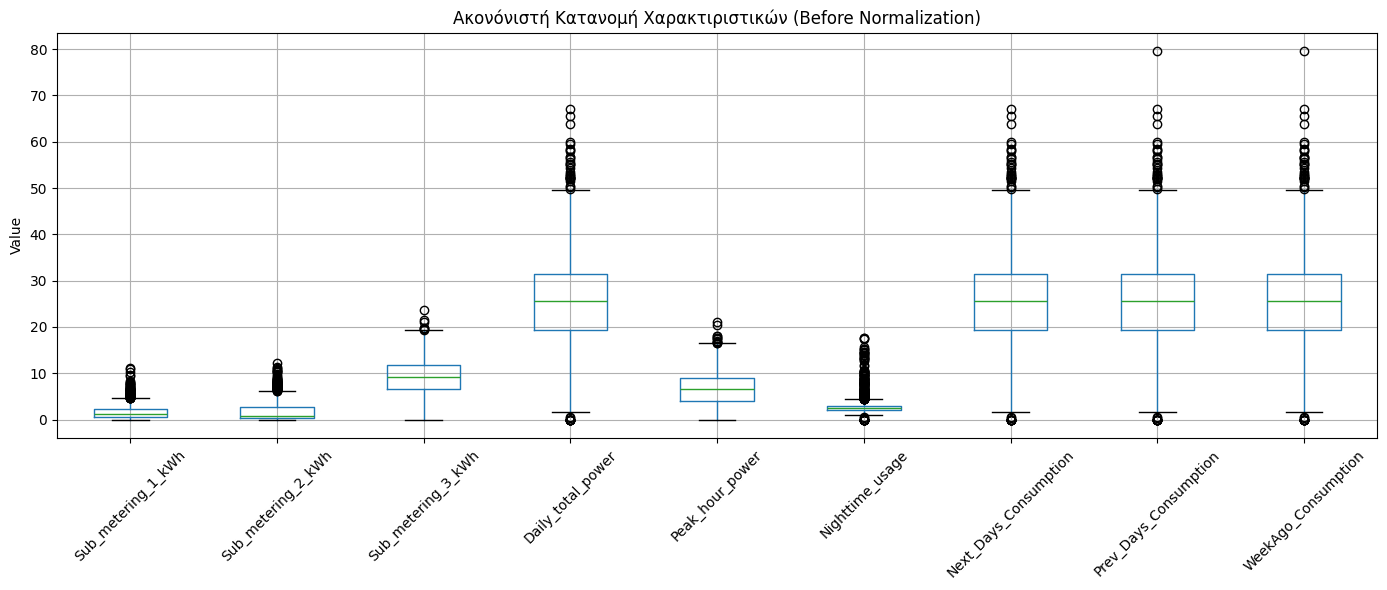

In [ ]:
# Οπτικοποίηση Ακανόνιστων Αριθμιτικών Χαρακτιριστικών του dataset
numeric_features = [
    'Sub_metering_1_kWh',
    'Sub_metering_2_kWh',
    'Sub_metering_3_kWh',
    'Daily_total_power',
    'Peak_hour_power',
    'Nighttime_usage',
#    'Weekend_usage',
    'Min_Temp_forecast',
    'Max_Temp_forecast',
    'Mean_Humidity_Percentage_forecast',
    'Cloud_cover_Mean_Percentage_forecast',
    'Next_Days_Consumption',
    'Prev_Days_Consumption',
    'WeekAgo_Consumption'
]

plt.figure(figsize=(14,6))
df_updated[numeric_features].boxplot()
plt.title("Ακονόνιστή Κατανομή Χαρακτιριστικών (Before Normalization)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


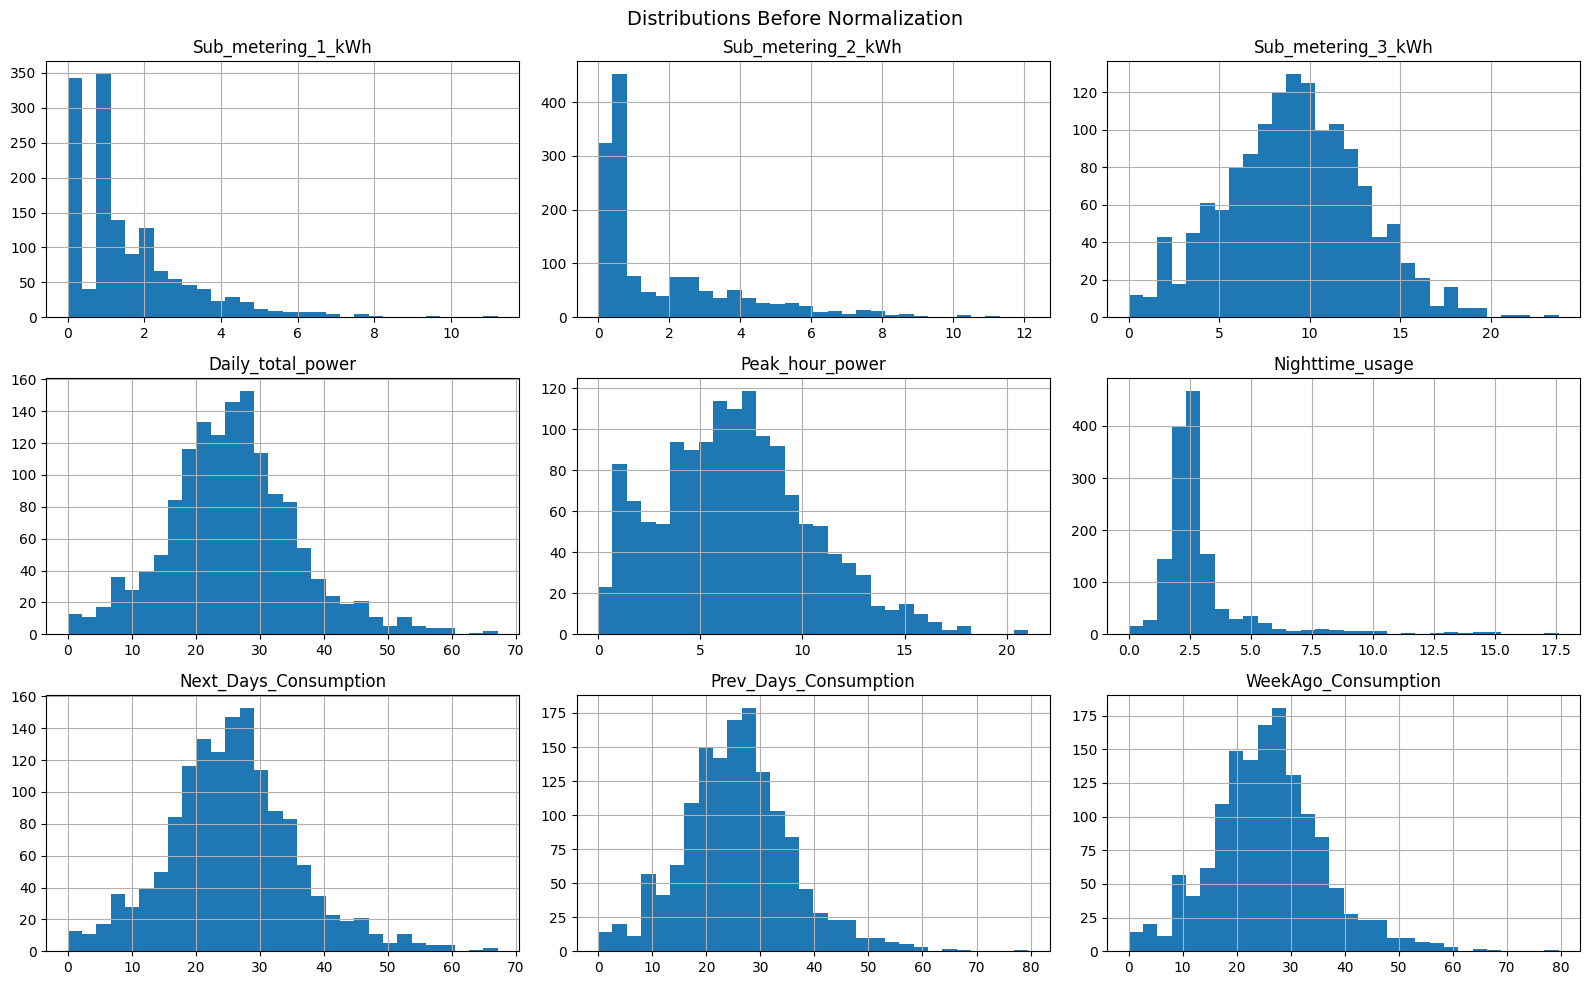

In [ ]:
import matplotlib.pyplot as plt

df_updated[numeric_features].hist(
    figsize=(16,10),
    bins=30
)
plt.suptitle("Distributions Before Normalization", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Χρήση του z-score normalazation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
daily_df_scaled = df_updated.copy()

daily_df_scaled[numeric_features] = scaler.fit_transform(df_updated[numeric_features])

daily_df_scaled[numeric_features].describe()

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power,Peak_hour_power,Nighttime_usage,Min_Temp_forecast,Max_Temp_forecast,Mean_Humidity_Percentage_forecast,Cloud_cover_Mean_Percentage_forecast,Next_Days_Consumption,Prev_Days_Consumption,WeekAgo_Consumption
count,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03
mean,-1.884203e-16,3.966742e-17,-3.966742e-17,4.958428e-18,-3.966742e-17,-1.983371e-17,-1.289191e-16,3.817990e-16,-6.247619e-16,-9.111111e-17,2.380045e-16,1.289191e-16,1.487528e-17
std,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00
min,-1.003429e+00,-8.825296e-01,-2.421042e+00,-2.534914e+00,-1.848793e+00,-1.427003e+00,-3.047702e+00,-2.421605e+00,-3.371690e+00,-2.390921e+00,-2.536086e+00,-2.514374e+00,-2.509559e+00
25%,-6.494212e-01,-6.789449e-01,-6.770325e-01,-6.390503e-01,-7.336746e-01,-4.510735e-01,-6.991481e-01,-7.141781e-01,-7.570073e-01,-6.216799e-01,-6.384367e-01,-6.367035e-01,-6.338694e-01
50%,-3.061023e-01,-5.577521e-01,1.687484e-02,-1.990693e-02,-2.502125e-02,-2.330590e-01,6.668450e-02,3.993527e-02,4.751033e-02,2.448874e-01,-1.879541e-02,-2.345277e-02,-2.696742e-02
75%,3.780202e-01,4.261609e-01,6.672149e-01,5.577286e-01,6.220129e-01,-1.119480e-03,8.325171e-01,8.082772e-01,7.514633e-01,8.225989e-01,5.575667e-01,5.488117e-01,5.481968e-01
max,6.054099e+00,4.917959e+00,3.848152e+00,4.069045e+00,3.909722e+00,7.004344e+00,2.279090e+00,2.800275e+00,2.159369e+00,1.219776e+00,4.074094e+00,5.233243e+00,5.211184e+00


In [ ]:
"""
print("UNSCALED STD")
print(df_updated[numeric_features].std())

print("\nSCALED STD")
print(daily_df_scaled[numeric_features].std())
"""
df_updated.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1433 entries, 2006-12-24 to 2010-11-25
Freq: D
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Sub_metering_1_kWh                    1433 non-null   float64
 1   Sub_metering_2_kWh                    1433 non-null   float64
 2   Sub_metering_3_kWh                    1433 non-null   float64
 3   Daily_total_power                     1433 non-null   float64
 4   Peak_hour_power                       1433 non-null   float64
 5   Nighttime_usage                       1433 non-null   float64
 6   Day_of_week                           1433 non-null   float64
 7   Month                                 1433 non-null   float64
 8   Season                                1433 non-null   float64
 9   is_workDay                            1433 non-null   float64
 10  Consumption                           1433 non-null   floa

In [ ]:
df_updated['Consumption'] = df_updated['Consumption'].astype('float64')
df_updated['Season'].replace({'Winter': float(0), 'Spring': float(1), 'Summer': float(2), 'Autumn': float(3)}, inplace=True)

In [ ]:
plt.figure(figsize=(14,6))
daily_df_scaled[numeric_features].boxplot()
plt.title("Κονονικοποιμένη Κατανομή Χαρακτιριστικών (Z-score Normalization)")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
daily_df_scaled[numeric_features].hist(
    figsize=(16,10),
    bins=30
)
plt.suptitle("Distributions After Z-score Normalization", fontsize=14)
plt.tight_layout()
plt.show()


«Επιλέχθηκε κανονικοποίηση τύπου Z-score αντί της Min–Max, καθώς τα δεδομένα περιέχουν ακραίες τιμές και σημαντικές διαφοροποιήσεις στην κατανάλωση. Η Z-score κανονικοποίηση διατηρεί τη σχετική απόσταση των παρατηρήσεων από τον μέσο όρο και είναι καταλληλότερη για αλγορίθμους ομαδοποίησης και παλινδρόμησης.»

In [ ]:
daily_df_scaled.to_pickle(os.path.join(OUTPUT_DIR, 'df_final.pkl'))
daily_df_scaled.to_csv(os.path.join(OUTPUT_DIR, 'df_final.csv'))

In [ ]:
daily_df_scaled

Αν θελω να οποτικοποιησω ενα χαρακτιριστικο που στον αξωνα Υ εχω 0-1 και στσο Χ εχω χαρακτιριστικο η ποιθανοτιτα το να βρω καποια τιμη στο χαος μεσα ειναι πολυ μικρη. Καλυτερα να συγκρινω 2 χαρακτιριστικα X1 X2

In [ ]:
daily_df_scaled.columns

In [ ]:
df_updated['Next_Days_Consumption'].std()

In [ ]:
df_updated['Daily_total_power'].std()

In [ ]:
df_updated['Daily_total_power'].describe()

In [ ]:
df_updated['WeekAgo_Consumption'].std()